In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
## 1: Load image paths and labels from TrainImages.txt and TestImages.txt

In [3]:
rootDir = '/kaggle/input/indoor-scenes-cvpr-2019/indoorCVPR_09/Images'

allData = []
for label in sorted(os.listdir(rootDir)):
    labelDir = os.path.join(rootDir, label)
    if os.path.isdir(labelDir):
        for file in os.listdir(labelDir):
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                imgPath = os.path.join(labelDir, file)
                allData.append((imgPath, label))

# 80-10-10 stratified split
trainData, tempData = train_test_split(
    allData, test_size=0.2, stratify=[label for _, label in allData], random_state=42
)
valData, testData = train_test_split(
    tempData, test_size=0.5, stratify=[label for _, label in tempData], random_state=42
)

labelNames = sorted(set([label for _, label in allData]))
labelToIndex = {label: idx for idx, label in enumerate(labelNames)}
classNames = labelNames

print(f"Loaded: Train = {len(trainData)}, Val = {len(valData)}, Test = {len(testData)}")


Loaded: Train = 12496, Val = 1562, Test = 1562


## 2: Create custom PyTorch Dataset using parsed image-label pairs


In [4]:

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
'''trainTransform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomAffine(degrees=15, shear=10),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])'''
trainTransform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=15, shear=10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


class SceneDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        imgPath, label = self.data[idx]
        image = Image.open(imgPath).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, labelToIndex[label]


In [5]:
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
from collections import Counter
import numpy as np

# Setup
batchSize = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Encode class labels
trainEncodedLabels = [labelToIndex[label] for _, label in trainData]
labelCounts = Counter(trainEncodedLabels)
numClasses = len(labelCounts)

#  Compute class weights (inverse frequency, normalized)
rawClassWeights = torch.tensor([1.0 / labelCounts[i] for i in range(numClasses)], dtype=torch.float)
classWeights = rawClassWeights / rawClassWeights.sum() * numClasses

# Assign per-sample weights
sampleWeights = torch.tensor([classWeights[label] for label in trainEncodedLabels])
print(f"Number of training samples: {len(trainEncodedLabels)}")
print(f"Sample weights size: {sampleWeights.size()}")

# Weighted sampler for imbalance handling
sampler = WeightedRandomSampler(
    weights=sampleWeights,
    num_samples=len(sampleWeights),
    replacement=True
)



# Datasets and Dataloaders
trainDataset = SceneDataset(trainData, trainTransform)
valDataset   = SceneDataset(valData, transform)
testDataset  = SceneDataset(testData, transform)

trainLoader = DataLoader(trainDataset, batch_size=batchSize, sampler=sampler)
valLoader   = DataLoader(valDataset, batch_size=batchSize, shuffle=False)
testLoader  = DataLoader(testDataset, batch_size=batchSize, shuffle=False)


Number of training samples: 12496
Sample weights size: torch.Size([12496])



Class Distribution in Train Set:
airport_inside      : 486
artstudio           : 112
auditorium          : 141
bakery              : 324
bar                 : 483
bathroom            : 158
bedroom             : 530
bookstore           : 304
bowling             : 170
buffet              : 89
casino              : 412
children_room       : 90
church_inside       : 144
classroom           : 90
cloister            : 96
closet              : 108
clothingstore       : 85
computerroom        : 91
concert_hall        : 82
corridor            : 277
deli                : 206
dentaloffice        : 105
dining_room         : 219
elevator            : 81
fastfood_restaurant : 93
florist             : 82
gameroom            : 102
garage              : 82
greenhouse          : 81
grocerystore        : 170
gym                 : 185
hairsalon           : 191
hospitalroom        : 81
inside_bus          : 82
inside_subway       : 366
jewelleryshop       : 126
kindergarden        : 102
kitchen           

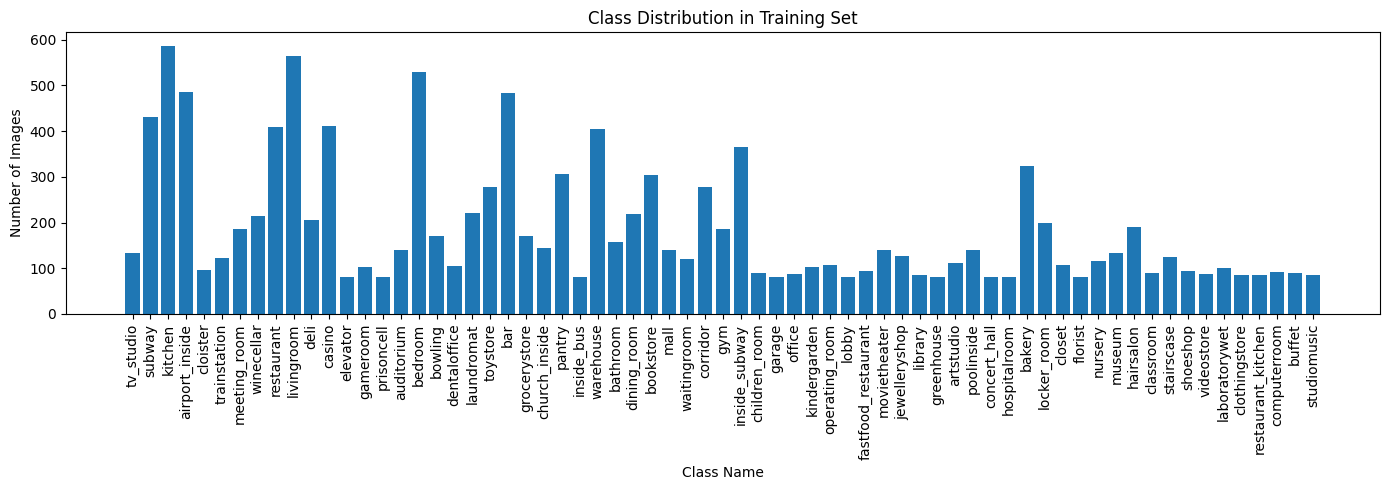

In [6]:
from collections import Counter
import matplotlib.pyplot as plt

# Count training samples per class
trainLabels = [label for _, label in trainData]
labelCounts = Counter(trainLabels)

# Print counts
print("\nClass Distribution in Train Set:")
for cls in sorted(labelCounts):
    print(f"{cls:20s}: {labelCounts[cls]}")

# Optional: plot class distribution
plt.figure(figsize=(14, 5))
plt.bar(labelCounts.keys(), labelCounts.values())
plt.xticks(rotation=90)
plt.title("Class Distribution in Training Set")
plt.xlabel("Class Name")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()


## 3: Create DataLoaders for training, validation, and testing


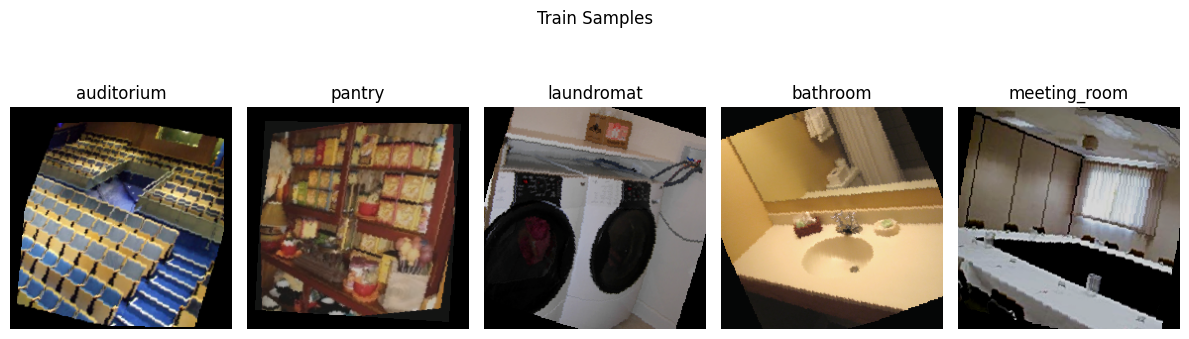

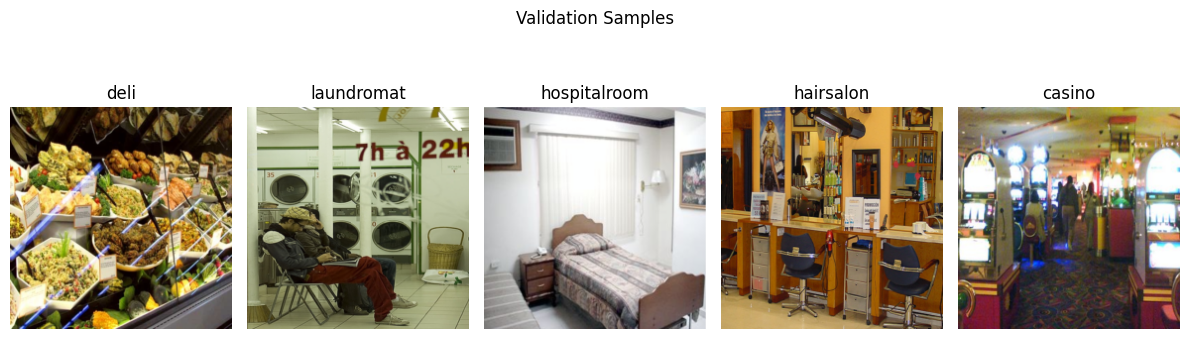

In [7]:

def showSamples(dataLoader, classNames, title="Sample Images"):
    images, labels = next(iter(dataLoader))
    plt.figure(figsize=(12, 4))
    for i in range(5):
        img = images[i].permute(1, 2, 0).numpy()  # Convert CHW → HWC
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  # Unnormalize
        img = np.clip(img, 0, 1)
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.title(classNames[labels[i].item()])
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

showSamples(trainLoader, classNames, title="Train Samples")
showSamples(valLoader, classNames, title="Validation Samples")


## 4: Define the custom multi-branch CNN using bottleneck Inception block


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Squeeze-and-Excitation Block with SiLU activation and customizable reduction
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):  # CHANGED: reduction = 8
        super(SEBlock, self).__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // reduction, kernel_size=1, bias=True),
            nn.SiLU(inplace=True),  # CHANGED: SiLU instead of ReLU
            nn.Conv2d(channels // reduction, channels, kernel_size=1, bias=True),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.fc(x)
        return x * scale

# Dense Layer with SEBlock
class DenseLayer(nn.Module):
    def __init__(self, in_channels, growth_rate):
        super(DenseLayer, self).__init__()
        self.bn = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv = nn.Conv2d(in_channels, growth_rate, kernel_size=3, padding=1, bias=False)
        self.se = SEBlock(growth_rate, reduction=8)  # Use SEBlock with SiLU

    def forward(self, x):
        out = self.conv(self.relu(self.bn(x)))
        out = self.se(out)
        return torch.cat([x, out], 1)

# Dense Block
class DenseBlock(nn.Module):
    def __init__(self, num_layers, in_channels, growth_rate):
        super(DenseBlock, self).__init__()
        layers = []
        for i in range(num_layers):
            layers.append(DenseLayer(in_channels + i * growth_rate, growth_rate))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

# Transition Layer
class TransitionLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(TransitionLayer, self).__init__()
        self.layer = nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.AvgPool2d(kernel_size=2, stride=2)
        )

    def forward(self, x):
        return self.layer(x)

# Final DenseNet-like Scene Classifier
class DenseNetLikeSceneClassifier(nn.Module):
    def __init__(self, growth_rate=32, block_layers=[4, 6, 8], num_classes=67):
        super(DenseNetLikeSceneClassifier, self).__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.features = nn.Sequential()
        num_channels = 64
        for i, num_layers in enumerate(block_layers):
            block = DenseBlock(num_layers, num_channels, growth_rate)
            self.features.add_module(f'denseblock{i+1}', block)
            num_channels = num_channels + num_layers * growth_rate
            if i != len(block_layers) - 1:
                trans = TransitionLayer(num_channels, num_channels // 2)
                self.features.add_module(f'transition{i+1}', trans)
                num_channels = num_channels // 2

        self.bn_final = nn.BatchNorm2d(num_channels)

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(num_channels, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.features(x)
        x = self.bn_final(x)
        x = self.classifier(x)
        return x


In [9]:
from torchinfo import summary

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DenseNetLikeSceneClassifier(
    growth_rate=32,
    block_layers=[4, 6, 8],
    num_classes=67
).to(device)



summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                                       Output Shape              Param #
DenseNetLikeSceneClassifier                                  [1, 67]                   --
├─Sequential: 1-1                                            [1, 64, 56, 56]           --
│    └─Conv2d: 2-1                                           [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                                      [1, 64, 112, 112]         128
│    └─ReLU: 2-3                                             [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                                        [1, 64, 56, 56]           --
├─Sequential: 1-2                                            [1, 400, 14, 14]          --
│    └─DenseBlock: 2-5                                       [1, 192, 56, 56]          --
│    │    └─Sequential: 3-1                                  [1, 192, 56, 56]          131,088
│    └─TransitionLayer: 2-6                                  [1, 96, 28, 28]          

In [10]:

#Loss Function 
criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1)

# Optimizer 
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=5e-5)

#Scheduler: OneCycleLR (optimal warmup + decay) -
epochs = 120
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=2e-4,
    steps_per_epoch=len(trainLoader),
    epochs=epochs,
    pct_start=0.1,
    anneal_strategy='cos',
    div_factor=25,
    final_div_factor=1e4
)

# Early Stopping 
earlyStopPatience = 15


In [11]:
import time

def trainModel(model, trainLoader, valLoader, criterion, optimizer, scheduler, 
               epochs=120, earlyStopPatience=5, max_grad_norm=None):
    bestValAcc = 0
    patienceCounter = 0

    trainAccList, valAccList, trainLossList, valLossList = [], [], [], []

    for epoch in range(epochs):
        start_time = time.time()

        model.train()
        totalTrainLoss, correctTrain, totalTrain = 0, 0, 0

        for images, labels in trainLoader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()

            if max_grad_norm:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

            optimizer.step()

            scheduler.step()

            totalTrainLoss += loss.item()
            _, preds = outputs.max(1)
            correctTrain += (preds == labels).sum().item()
            totalTrain += labels.size(0)

        trainAcc = correctTrain / totalTrain
        trainLoss = totalTrainLoss / len(trainLoader)

        valLoss, valAcc = evaluateModel(model, valLoader, criterion)

        trainAccList.append(trainAcc)
        valAccList.append(valAcc)
        trainLossList.append(trainLoss)
        valLossList.append(valLoss)

        elapsed_time = time.time() - start_time
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Current LR: {current_lr:.6f}")
        print(f"Epoch {epoch+1:02d} | Train Acc: {trainAcc:.4f} | Val Acc: {valAcc:.4f} | "
              f"Train Loss: {trainLoss:.4f} | Val Loss: {valLoss:.4f} | Time: {elapsed_time:.2f}s")

        if valAcc > bestValAcc:
            bestValAcc = valAcc
            patienceCounter = 0
            torch.save(model.state_dict(), "bestModelv2.pth")
        else:
            patienceCounter += 1
            if patienceCounter >= earlyStopPatience:
                print("Early stopping triggered.")
                break

    return trainAccList, valAccList, trainLossList, valLossList


In [12]:

def evaluateModel(model, dataLoader, criterion):
    model.eval()
    totalLoss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in dataLoader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            totalLoss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avgLoss = totalLoss / len(dataLoader)
    accuracy = correct / total
    return avgLoss, accuracy

In [13]:
trainAccList, valAccList, trainLossList, valLossList = trainModel(
    model, trainLoader, valLoader, criterion, optimizer, scheduler,
    epochs=120, earlyStopPatience=earlyStopPatience,max_grad_norm=1.0
)


Current LR: 0.000011
Epoch 01 | Train Acc: 0.0388 | Val Acc: 0.0640 | Train Loss: 4.1460 | Val Loss: 4.0506 | Time: 262.89s
Current LR: 0.000021
Epoch 02 | Train Acc: 0.0725 | Val Acc: 0.0698 | Train Loss: 3.9859 | Val Loss: 3.8894 | Time: 216.24s
Current LR: 0.000036
Epoch 03 | Train Acc: 0.0915 | Val Acc: 0.0864 | Train Loss: 3.8620 | Val Loss: 3.7755 | Time: 205.96s
Current LR: 0.000056
Epoch 04 | Train Acc: 0.1164 | Val Acc: 0.1063 | Train Loss: 3.7429 | Val Loss: 3.6645 | Time: 207.87s
Current LR: 0.000079
Epoch 05 | Train Acc: 0.1531 | Val Acc: 0.1204 | Train Loss: 3.6270 | Val Loss: 3.5849 | Time: 203.73s
Current LR: 0.000104
Epoch 06 | Train Acc: 0.1662 | Val Acc: 0.1332 | Train Loss: 3.5371 | Val Loss: 3.5391 | Time: 204.21s
Current LR: 0.000129
Epoch 07 | Train Acc: 0.1798 | Val Acc: 0.1485 | Train Loss: 3.4760 | Val Loss: 3.4937 | Time: 202.83s
Current LR: 0.000152
Epoch 08 | Train Acc: 0.1944 | Val Acc: 0.1364 | Train Loss: 3.3822 | Val Loss: 3.5729 | Time: 201.60s
Current 

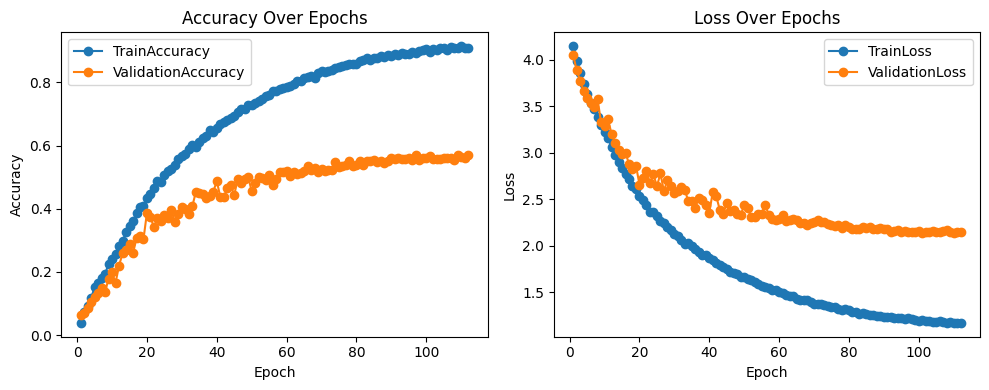

In [14]:
import matplotlib.pyplot as plt

def plotAccuracyLoss(trainAccList, valAccList, trainLossList, valLossList):
    Epochs = range(1, len(trainAccList) + 1)

    # Accuracy Plot
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(Epochs, trainAccList, label='TrainAccuracy', marker='o')
    plt.plot(Epochs, valAccList, label='ValidationAccuracy', marker='o')
    plt.title('Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(Epochs, trainLossList, label='TrainLoss', marker='o')
    plt.plot(Epochs, valLossList, label='ValidationLoss', marker='o')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plotAccuracyLoss(trainAccList, valAccList, trainLossList, valLossList)


In [15]:
model.load_state_dict(torch.load("bestModelv2.pth"))
testLoss, testAcc = evaluateModel(model, testLoader, criterion)
print(f"Test Accuracy: {testAcc*100:.4f} Test Loss: {testLoss:.4f}")

Test Accuracy: 56.0819 Test Loss: 2.1122


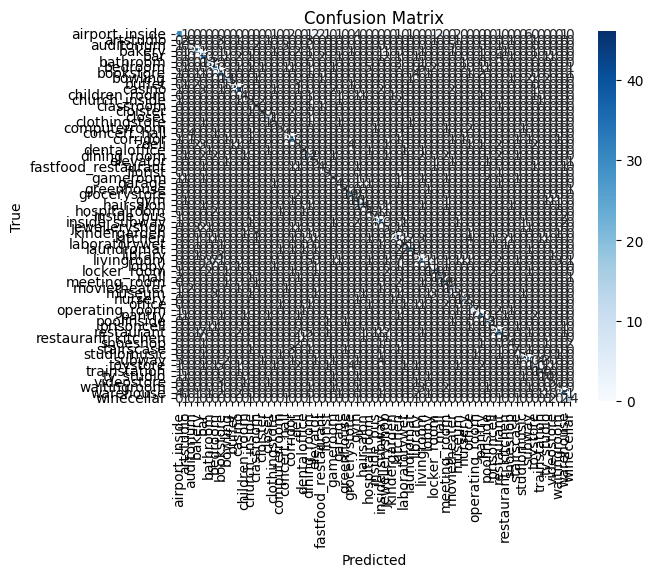

                     precision    recall  f1-score   support

     airport_inside       0.53      0.51      0.52        61
          artstudio       0.15      0.14      0.15        14
         auditorium       0.42      0.29      0.34        17
             bakery       0.65      0.63      0.64        41
                bar       0.53      0.57      0.55        61
           bathroom       0.50      0.65      0.57        20
            bedroom       0.62      0.53      0.57        66
          bookstore       0.52      0.66      0.58        38
            bowling       0.62      0.59      0.60        22
             buffet       0.75      0.27      0.40        11
             casino       0.73      0.73      0.73        51
      children_room       0.50      0.36      0.42        11
      church_inside       0.44      0.44      0.44        18
          classroom       0.50      0.73      0.59        11
           cloister       0.69      0.75      0.72        12
             closet    

In [16]:
allLabels, allPreds = [], []
model.eval()
with torch.no_grad():
    for images, labels in testLoader:
        images = images.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        allLabels.extend(labels.cpu().numpy())
        allPreds.extend(preds.cpu().numpy())

cm = confusion_matrix(allLabels, allPreds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classNames, yticklabels=classNames, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(allLabels, allPreds, target_names=classNames))


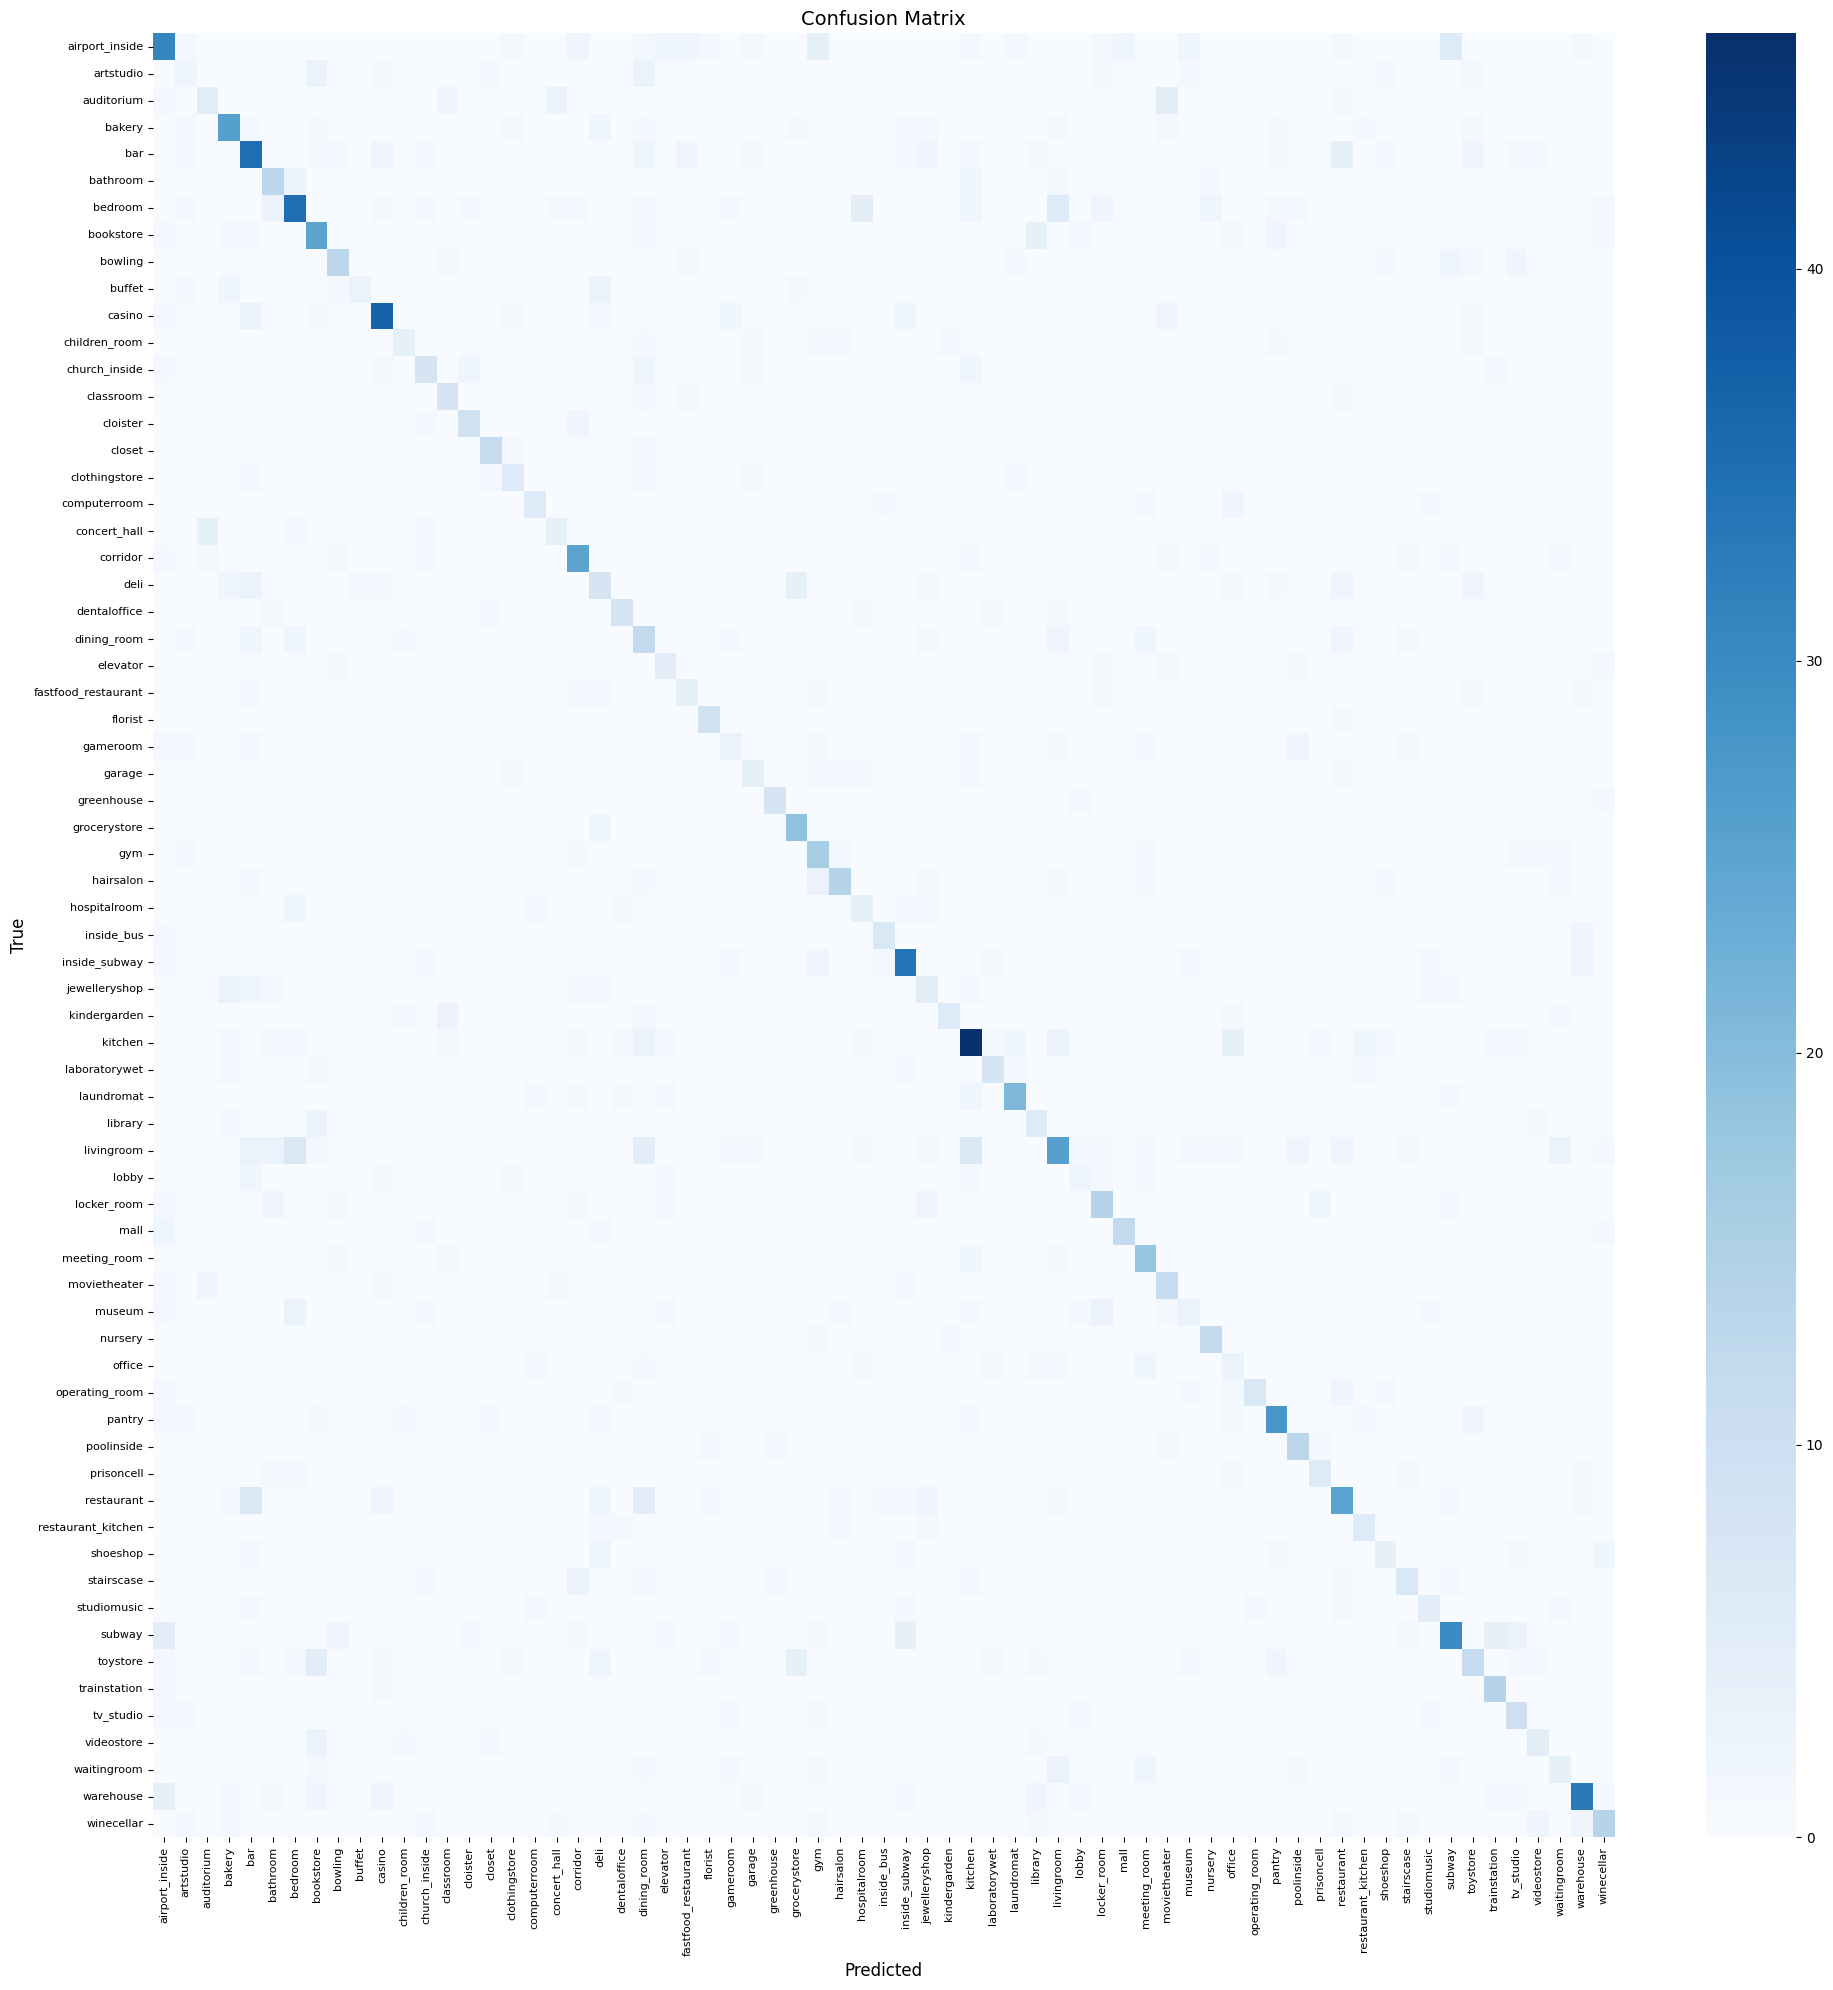

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Compute confusion matrix
cm = confusion_matrix(allLabels, allPreds)

# Set figure size to avoid label overlap
plt.figure(figsize=(20, 20))

# Plot the heatmap with no annotations to keep it clean
sns.heatmap(cm, cmap='Blues', xticklabels=classNames, yticklabels=classNames)

plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("True", fontsize=12)
plt.title("Confusion Matrix", fontsize=14)
plt.tight_layout()
plt.show()
